<a href="https://colab.research.google.com/github/AbhishekCodes0615/Libary-book-finder/blob/main/medical_ins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape: (1338, 7)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Statistical Summary:

           

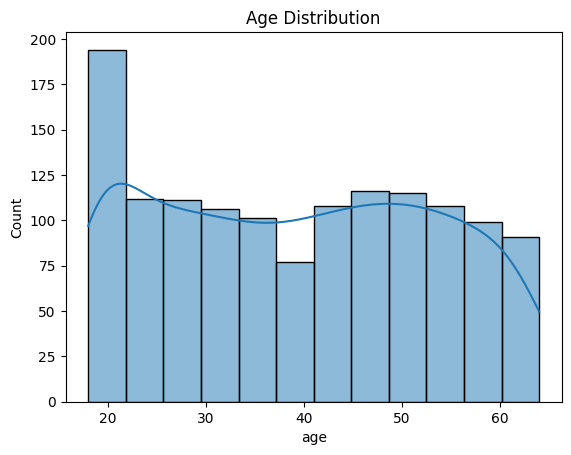

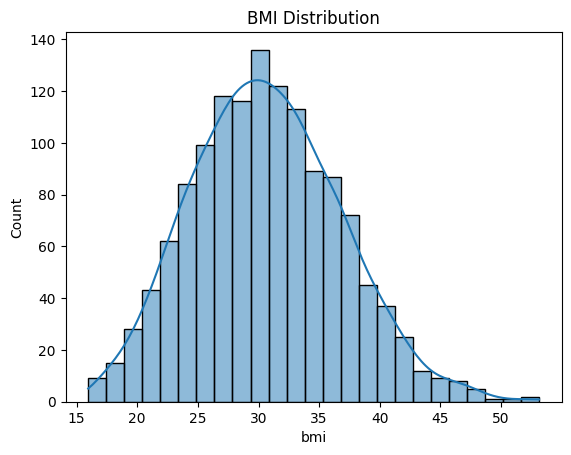

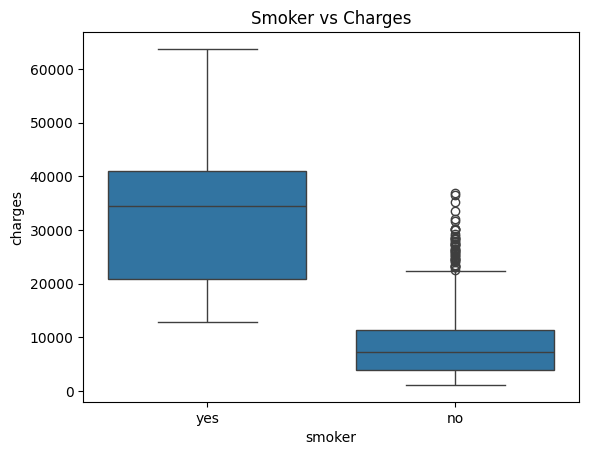


Encoded Dataset:

   age  sex     bmi  children  smoker  region      charges
0   19    1  27.900         0       1       1  16884.92400
1   18    0  33.770         1       0       0   1725.55230
2   28    0  33.000         3       0       0   4449.46200
3   33    0  22.705         0       0       3  21984.47061
4   32    0  28.880         0       0       3   3866.85520

Training Data Shape: (1070, 6)
Testing Data Shape: (268, 6)

Model Training Completed!

📊 Model Evaluation:

Training R2 Score: 0.7413131194887537
Testing R2 Score: 0.783021587162344

Mean Absolute Error: 4190.220190137917
Mean Squared Error: 33685623.35414443
Root Mean Squared Error: 5803.931715151758

Predicted Insurance Cost: ₹ 5439.467825872884

Model saved as insurance_model.pkl


/tmp/ipykernel_439/2402278347.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
# ==========================================
# Medical Insurance Cost Prediction Project
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

data = pd.read_csv('/content/Medical Insurance/insurance.csv')

print("First 5 Rows:\n")
print(data.head())

print("\nDataset Shape:", data.shape)
print("\nDataset Info:\n")
print(data.info())

print("\nStatistical Summary:\n")
print(data.describe())

print("\nMissing Values:\n")
print(data.isnull().sum())

plt.figure()
sns.histplot(data['age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure()
sns.histplot(data['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()


plt.figure()
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Smoker vs Charges")
plt.show()


data.replace({
    'sex': {'male': 0, 'female': 1},
    'smoker': {'yes': 1, 'no': 0},
    'region': {
        'southeast': 0,
        'southwest': 1,
        'northeast': 2,
        'northwest': 3
    }
}, inplace=True)

print("\nEncoded Dataset:\n")
print(data.head())

X = data.drop(columns='charges')
Y = data['charges']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

model = LinearRegression()
model.fit(X_train, Y_train)

print("\nModel Training Completed!")

train_pred = model.predict(X_train)

test_pred = model.predict(X_test)

print("\n📊 Model Evaluation:")

print("\nTraining R2 Score:", r2_score(Y_train, train_pred))
print("Testing R2 Score:", r2_score(Y_test, test_pred))

print("\nMean Absolute Error:", mean_absolute_error(Y_test, test_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, test_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, test_pred)))



input_data = (30, 1, 28.5, 1, 0, 2)
input_array = np.array(input_data).reshape(1, -1)

prediction = model.predict(input_array)

print("\nPredicted Insurance Cost: ₹", prediction[0])

import pickle

with open("insurance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel saved as insurance_model.pkl")

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest R2 Score:", r2_score(Y_test, rf_pred))

Random Forest R2 Score: 0.8647587097644911


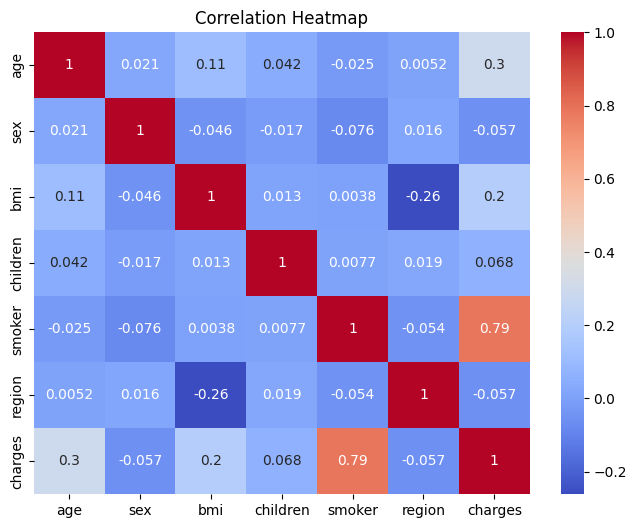

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Improvement Strategy: Log Transformation of Target Variable

One common approach to address heteroscedasticity (non-constant variance of errors) and to make skewed target distributions more normal is to apply a logarithmic transformation to the target variable. Let's apply `np.log()` to the `charges` column and then retrain and re-evaluate the model.

In [13]:
# 1️⃣ Apply log transformation to the target variable (charges)
# We will transform Y (charges) and then reverse the transform for predictions
Y_log = np.log(data['charges'])

# 2️⃣ Train-Test Split with transformed target
X_train_log, X_test_log, Y_train_log, Y_test_log = train_test_split(
    X, Y_log, test_size=0.2, random_state=42
)

print("\nTraining Data Shape (features):", X_train_log.shape)
print("Testing Data Shape (features):", X_test_log.shape)
print("Training Data Shape (log-transformed target):", Y_train_log.shape)
print("Testing Data Shape (log-transformed target):", Y_test_log.shape)

# 3️⃣ Train Linear Regression Model with log-transformed target
model_log = LinearRegression()
model_log.fit(X_train_log, Y_train_log)

print("\nModel Training with log-transformed target Completed!")

# 4️⃣ Model Evaluation with log-transformed target

# Training Prediction (log-transformed)
train_pred_log = model_log.predict(X_train_log)
# Inverse transform to get actual currency values
train_pred_actual = np.exp(train_pred_log)

# Testing Prediction (log-transformed)
test_pred_log = model_log.predict(X_test_log)
# Inverse transform to get actual currency values
test_pred_actual = np.exp(test_pred_log)

# Inverse transform original Y_test_log to compare with actual predictions
Y_test_actual = np.exp(Y_test_log)
Y_train_actual = np.exp(Y_train_log)

print("\n📊 Model Evaluation (with log-transformed target):")

print("\nTraining R2 Score:", r2_score(Y_train_actual, train_pred_actual))
print("Testing R2 Score:", r2_score(Y_test_actual, test_pred_actual))

print("\nMean Absolute Error:", mean_absolute_error(Y_test_actual, test_pred_actual))
print("Mean Squared Error:", mean_squared_error(Y_test_actual, test_pred_actual))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test_actual, test_pred_actual)))

# 5️⃣ Predict for New Custom Data (with log-transformed target)
# Format: age, sex, bmi, children, smoker, region

input_data_custom = (30, 1, 28.5, 1, 0, 2)  # Example person
input_array_custom = np.array(input_data_custom).reshape(1, -1)

prediction_log = model_log.predict(input_array_custom)
prediction_actual = np.exp(prediction_log)

print("\nPredicted Insurance Cost (with log transform): ₹", prediction_actual[0])


Training Data Shape (features): (1070, 6)
Testing Data Shape (features): (268, 6)
Training Data Shape (log-transformed target): (1070,)
Testing Data Shape (log-transformed target): (268,)

Model Training with log-transformed target Completed!

📊 Model Evaluation (with log-transformed target):

Training R2 Score: 0.5137587133172137
Testing R2 Score: 0.6016045962029892

Mean Absolute Error: 3925.2416856737823
Mean Squared Error: 61850381.07163879
Root Mean Squared Error: 7864.501323773733

Predicted Insurance Cost (with log transform): ₹ 4885.790637422971


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Re-analyze the Distribution of Prediction Errors (after log transformation)

Let's re-examine the residuals to see if the log transformation improved their distribution and reduced heteroscedasticity.

In [14]:
# Calculate residuals using actual values after inverse transformation
residuals_log = Y_test_actual - test_pred_actual

print("Residuals head (log-transformed model):\n", residuals_log.head())
print("\nResiduals describe (log-transformed model):\n", residuals_log.describe())

Residuals head (log-transformed model):
 764       528.500796
887      -514.331883
890    -39137.484690
1293     -123.114624
259     19183.063162
Name: charges, dtype: float64

Residuals describe (log-transformed model):
 count      268.000000
mean       -27.250799
std       7879.167789
min     -39137.484690
25%      -1084.973945
50%       -484.330845
75%        456.002299
max      23668.006711
Name: charges, dtype: float64


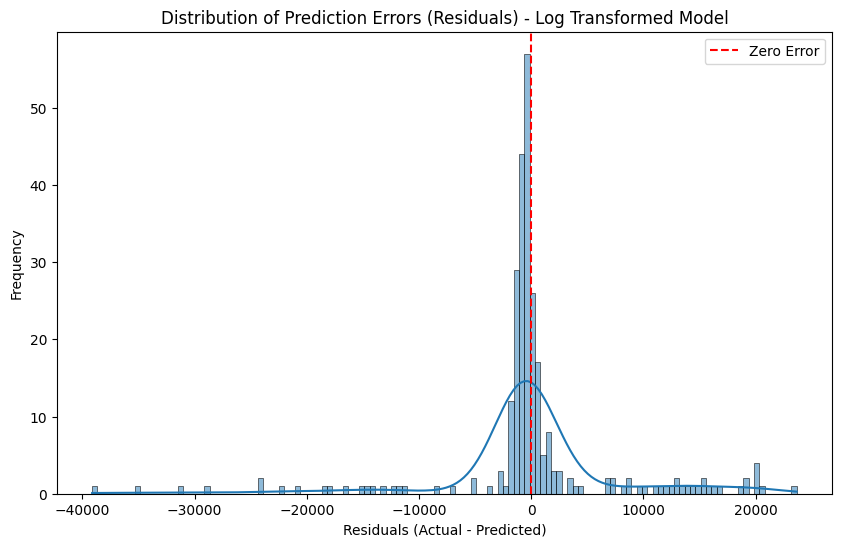

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals_log, kde=True)
plt.title('Distribution of Prediction Errors (Residuals) - Log Transformed Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

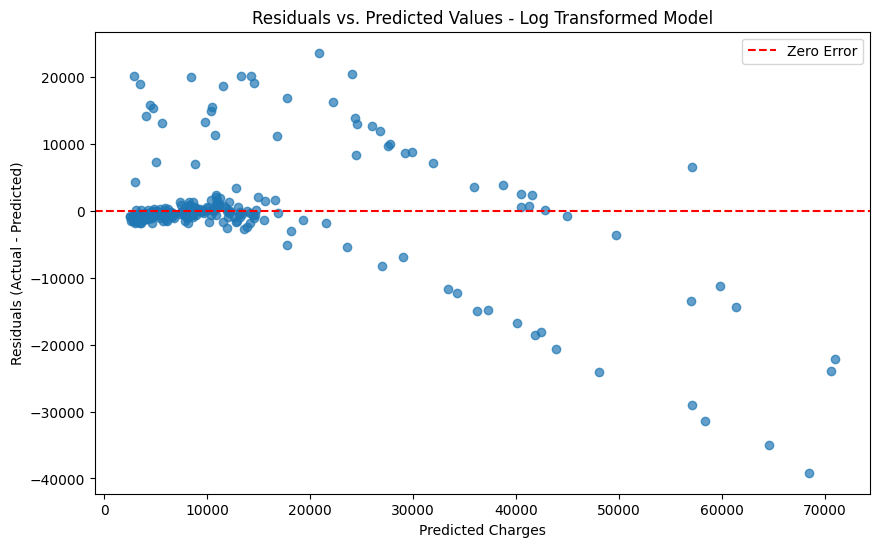

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(test_pred_actual, residuals_log, alpha=0.7)
plt.title('Residuals vs. Predicted Values - Log Transformed Model')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

### Analyze the Distribution of Prediction Errors

In [10]:
# Calculate residuals (prediction errors)
residuals = Y_test - test_pred

print("Residuals head:\n", residuals.head())
print("\nResiduals describe:\n", residuals.describe())

Residuals head:
 764      497.783355
887    -1959.568082
890    -7708.248940
1293    -314.318579
259     6589.136753
Name: charges, dtype: float64

Residuals describe:
 count      268.000000
mean      -228.279359
std       5810.290879
min     -10500.436636
25%      -3065.279399
50%      -1231.687523
75%       1514.032712
max      22917.024939
Name: charges, dtype: float64


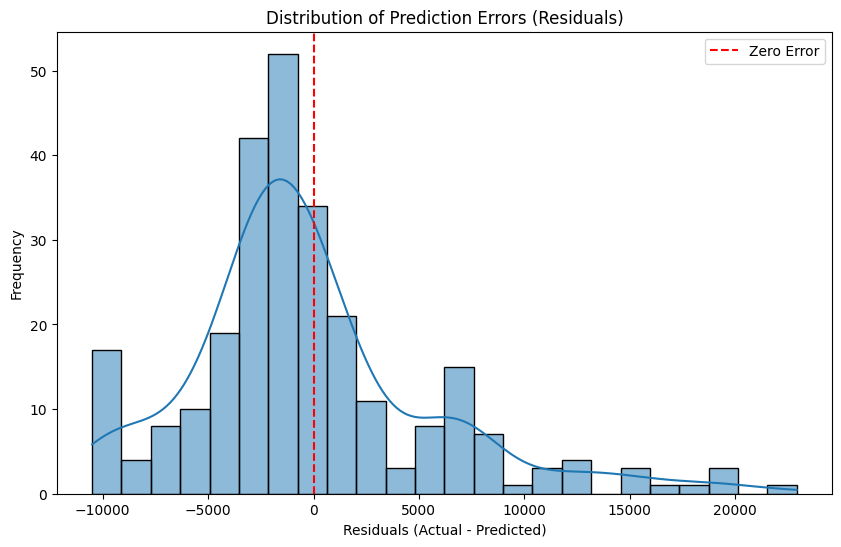

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

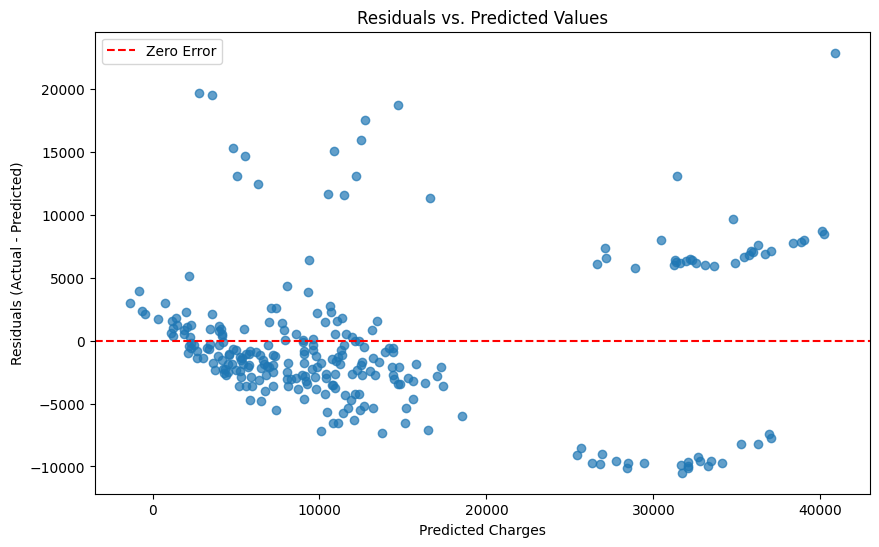

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(test_pred, residuals, alpha=0.7)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

### Interpreting the Residuals Plots

*   **Histogram of Residuals:** Ideally, the residuals should be normally distributed around zero. This means the histogram should look like a bell curve centered at zero.
*   **Residuals vs. Predicted Values Plot:** This scatter plot helps to identify if the errors are randomly distributed or if there's a pattern. Ideally, the points should be randomly scattered around the horizontal line at zero, with no discernible pattern (e.g., no funnel shape, no curve). A pattern here could indicate that the model is not capturing some underlying relationship or that the variance of the errors is not constant (heteroscedasticity).

In [8]:
!unrar x "/content/Medical Insurance (1).rar"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Medical Insurance (1).rar

Creating    Medical Insurance                                         OK
Extracting  Medical Insurance/insurance.csv                               15%  OK 
Extracting  Medical Insurance/Medical_Insurance_Cost_Prediction.ipynb      46% 78% 99%  OK 
All OK
